In [1]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/arbiter/projects/grb-classification/vyom_venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3549, in run_code
  File "/tmp/ipykernel_795/1220816136.py", line 1, in <module>
    import numpy as np
ModuleNotFoundError: No module named 'numpy'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/arbiter/projects/grb-classification/vyom_venv/lib/python3.12/site-packages/pygments/styles/__init__.py", line 45, in get_style_by_name
ModuleNotFoundError: No module named 'pygments.styles.default'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/arbiter/projects/grb-classification/vyom_venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 2173, in showtraceback
  File "/home/arbiter/projects/grb-classification/vyom_venv/lib/python3.12/site-packages/IPython/core/ultratb.py"

In [2]:
df = pd.read_csv("swift_burst_data.txt", delimiter= "\t", encoding = "latin1")

In [3]:
df.head(2)

,GRB,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],...,UVOT 90% Error Radius [arcsec],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,Redshift,Host Galaxy,Comments,References,Burst Advocate
0,250331C,04:37:40,1299967,80.993,33.029,3,NaN,NaN,NaN,NaN,...,NaN,139,NaN,NaN,NaN,NaN,NaN,NaN,BAT: GCN 39959|XRT: GCN 39959; GCN 39960; GCN ...,Brad Cenko
1,250331B,04:19:43,1299965,71.381,43.805,3,NaN,NaN,NaN,NaN,...,NaN,317,NaN,White>19.6,NaN,NaN,NaN,NaN,BAT: GCN 39958|XRT: GCN 39958; GCN 39974; GCN ...,Brad Cenko


In [4]:
df.describe()

,BAT RA (J2000),BAT Dec (J2000),BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],XRT 90% Error Radius [arcsec],XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2]
count,1698.000000,1698.000000,1551.000000,1547.000000,1381.000000,1353.000000,1405.000000,1405.000000
mean,180.874866,2.831430,4.139852,0.313142,1.910913,0.155228,2.062960,5.623895
std,104.353416,41.386243,12.605058,0.324452,0.985266,0.527018,1.286381,10.769524
min,0.127000,-89.029000,0.000000,0.000000,1.400000,-0.157401,0.883481,0.000000
25%,89.500500,-30.265250,0.800000,0.200000,1.400000,0.015167,1.822810,1.080055
50%,186.046500,3.576000,1.500000,0.200000,1.500000,0.045327,1.995570,2.589120
75%,270.876250,36.076250,3.400000,0.300000,2.000000,0.125770,2.171190,5.765250
max,358.751000,89.180000,331.000000,4.600000,15.000000,11.349125,47.177400,198.137000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 35 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   GRB                                                                            1699 non-null   object 
 1   Time [UT]                                                                      1691 non-null   object 
 2   Trigger Number                                                                 1699 non-null   object 
 3   BAT RA (J2000)                                                                 1698 non-null   float64
 4   BAT Dec (J2000)                                                                1698 non-null   float64
 5   BAT 90% Error Radius [arcmin]                                                  1690 non-null   object 
 6   BAT T90 [sec]           

# EDA and Data Cleaning

### Inspecting data

<Axes: >

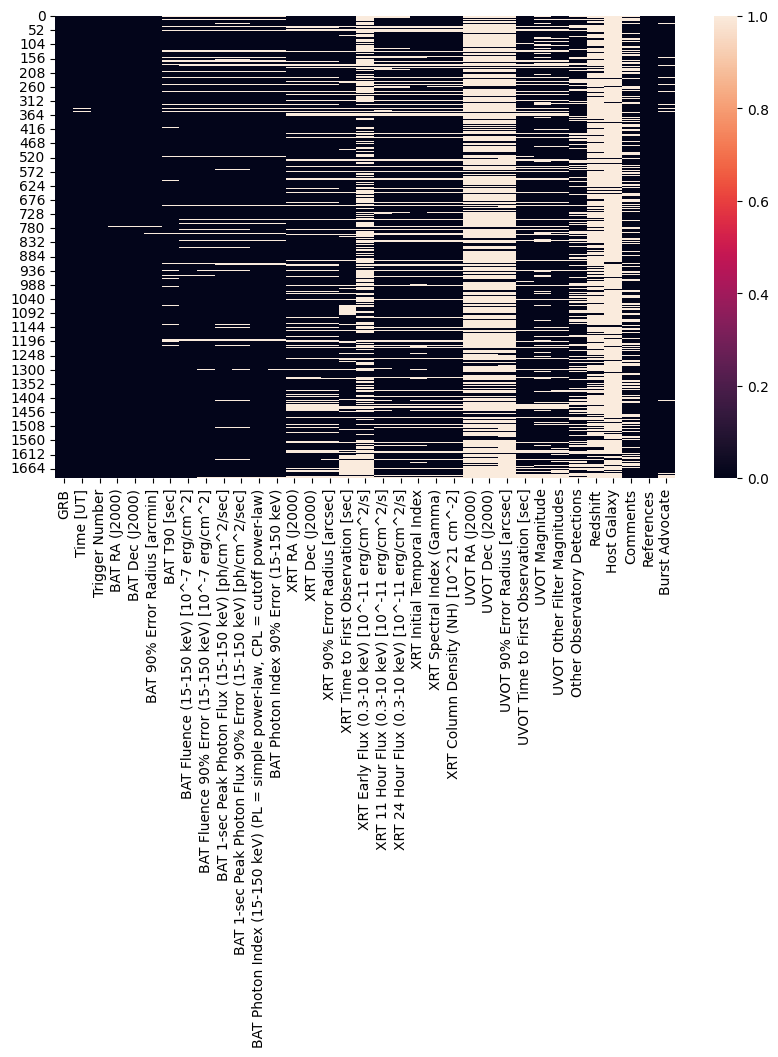

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull())

Getting all the columns which are dtype numerical (float)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 35 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   GRB                                                                            1699 non-null   object 
 1   Time [UT]                                                                      1691 non-null   object 
 2   Trigger Number                                                                 1699 non-null   object 
 3   BAT RA (J2000)                                                                 1698 non-null   float64
 4   BAT Dec (J2000)                                                                1698 non-null   float64
 5   BAT 90% Error Radius [arcmin]                                                  1690 non-null   object 
 6   BAT T90 [sec]           

In [8]:
df.describe()

,BAT RA (J2000),BAT Dec (J2000),BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],XRT 90% Error Radius [arcsec],XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2]
count,1698.000000,1698.000000,1551.000000,1547.000000,1381.000000,1353.000000,1405.000000,1405.000000
mean,180.874866,2.831430,4.139852,0.313142,1.910913,0.155228,2.062960,5.623895
std,104.353416,41.386243,12.605058,0.324452,0.985266,0.527018,1.286381,10.769524
min,0.127000,-89.029000,0.000000,0.000000,1.400000,-0.157401,0.883481,0.000000
25%,89.500500,-30.265250,0.800000,0.200000,1.400000,0.015167,1.822810,1.080055
50%,186.046500,3.576000,1.500000,0.200000,1.500000,0.045327,1.995570,2.589120
75%,270.876250,36.076250,3.400000,0.300000,2.000000,0.125770,2.171190,5.765250
max,358.751000,89.180000,331.000000,4.600000,15.000000,11.349125,47.177400,198.137000


In [9]:
df.shape

(1699, 35)

### Inspecting the data

/tmp/ipykernel_829/1691677136.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["BAT RA (J2000)"], label = "Right Ascension")
/tmp/ipykernel_829/1691677136.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["BAT Dec (J2000)"], label = "Declination")


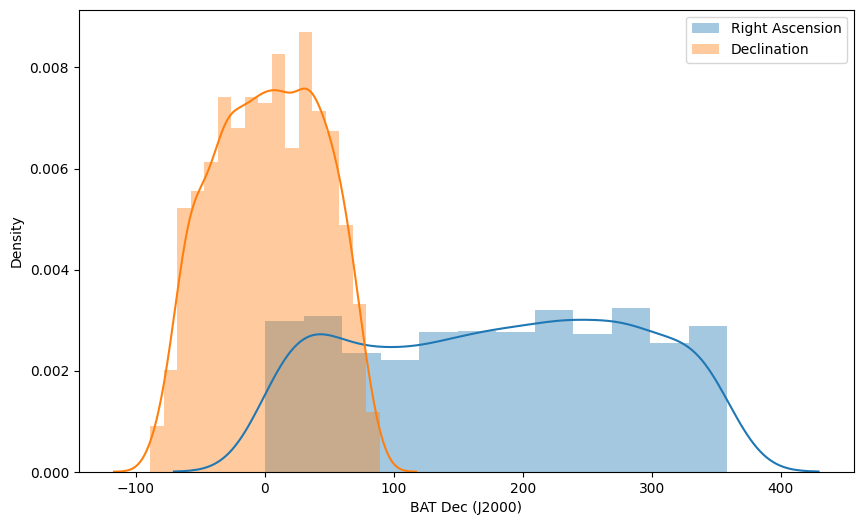

In [12]:
plt.figure(figsize=(10,6))
sns.distplot(df["BAT RA (J2000)"], label = "Right Ascension")
sns.distplot(df["BAT Dec (J2000)"], label = "Declination")
plt.legend()

/tmp/ipykernel_829/2787158409.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]"])


<Axes: xlabel='BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]', ylabel='Density'>

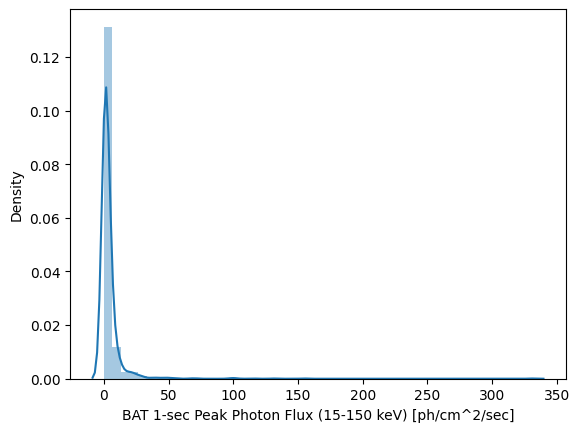

In [13]:
sns.distplot(df["BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]"])

/tmp/ipykernel_829/1624953894.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]"])


<Axes: xlabel='BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]', ylabel='Density'>

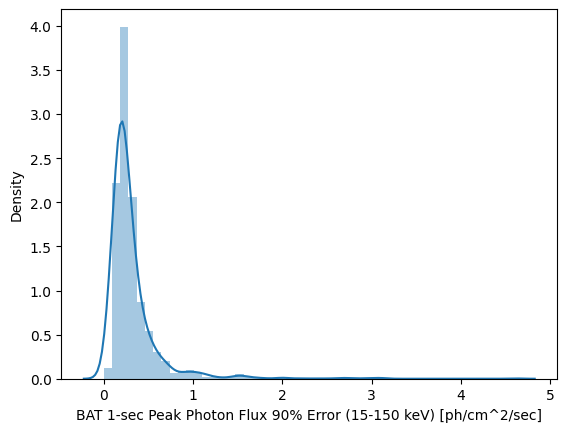

In [14]:
sns.distplot(df["BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]"])